In [1]:
!pip install -q sentence-transformers faiss-cpu rank-bm25 \
    transformers peft torch evaluate rouge_score bert_score \
    PyMuPDF

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 79.6 MB/s eta 0:00:00


In [2]:
!pip install --upgrade torchao peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [3]:
import os, re, json
import numpy as np
import torch
import fitz  # PyMuPDF
import faiss
from pathlib import Path
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


Load notes

In [4]:
from google.colab import drive
drive.mount('/content/drive')
NOTES_DIR = "/content/drive/MyDrive/372-Project/data"
os.makedirs(NOTES_DIR, exist_ok=True)

def load_txt(path):
    return Path(path).read_text(encoding="utf-8")

def load_pdf(path):
    doc = fitz.open(path)
    return "\n".join(page.get_text() for page in doc)

def load_all_notes(directory):
    texts = []
    for f in Path(directory).iterdir():
        if f.suffix == ".txt":
            texts.append(load_txt(f))
        elif f.suffix == ".pdf":
            texts.append(load_pdf(f))
    full = "\n\n".join(texts)
    print(f"Loaded {len(texts)} file(s), {len(full):,} characters total")
    return full



raw_text = load_all_notes(NOTES_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 1 file(s), 405,798 characters total


Custom chunking strategy using semantic chunking

In [5]:


def chunk_semantic(text, min_len=100, max_len=600):
    """Strategy B: paragraph/section-aware chunking.
    Splits on blank lines or headings, then merges short fragments.
    Respects natural topic boundaries in student notes.
    """
    raw = re.split(r'\n{2,}|(?=\n(?:Chapter|Section|##|\d+\.))', text)
    chunks, buffer = [], ""
    for block in raw:
        block = block.strip()
        if not block:
            continue
        buffer = (buffer + " " + block).strip() if buffer else block
        if len(buffer.split()) >= min_len:
            if len(buffer.split()) > max_len:
                sentences = re.split(r'(?<=[.!?])\s+', buffer)
                sub, cur = [], ""
                for s in sentences:
                    if len((cur + " " + s).split()) < max_len:
                        cur = (cur + " " + s).strip()
                    else:
                        if cur: sub.append(cur)
                        cur = s
                if cur: sub.append(cur)
                chunks.extend(sub)
            else:
                chunks.append(buffer)
            buffer = ""
    if buffer:
        chunks.append(buffer)
    return [c for c in chunks if len(c.split()) >= 20]

chunks_semantic = chunk_semantic(raw_text)


chunks = chunks_semantic
print(f"\nUsing semantic chunks: {len(chunks)} total")
for i, c in enumerate(chunks[:3]):
    print(f"\n[Chunk {i}] {c[:120]}...")


Using semantic chunks: 287 total

[Chunk 0] PHILOSOPHY
101
FROM PLATO AND SOCRATES TO
ETHICS AND METAPHYSICS, AN
ESSENTIAL PRIMER ON THE
HISTORY OF THOUGHT
PAUL KLE...

[Chunk 1] PHILOSOPHY OF SCIENCE
BARUCH SPINOZA (1632–1677)
PHILOSOPHY OF RELIGION
Copyright INTRODUCTION
What Is Philosophy?
The v...

[Chunk 2] 1. Metaphysics: The study of the universe and reality 2. Logic: How to create a valid argument 3. Epistemology: The stud...


Embed Chunks & Build FAISS Index

In [6]:
from google.colab import drive
drive.mount('/content/drive')
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

chunk_embeddings = embedder.encode(
    chunks,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
).astype("float32")

dim   = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)   # inner product = cosine on normalized vecs
index.add(chunk_embeddings)

print(f"FAISS index: {index.ntotal} vectors, dim={dim}")


faiss.write_index(index, "/content/drive/MyDrive/372-Project/models/notes.faiss")
with open("/content/drive/MyDrive/372-Project/models/chunks.json", "w") as f:
    json.dump(chunks, f)
print("Index and chunks saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

FAISS index: 287 vectors, dim=384
Index and chunks saved.


Dense retriever

In [7]:
def retrieve_dense(query, k=10):
    """Semantic retrieval via FAISS cosine similarity."""
    q_emb = embedder.encode(
        [query], normalize_embeddings=True
    ).astype("float32")
    scores, indices = index.search(q_emb, k)
    return [(int(i), float(s)) for i, s in zip(indices[0], scores[0]) if i >= 0]

# Smoke test
test_results = retrieve_dense("Who was Thomas Hobbes?", k=3)
print("Top 3 dense results:")
for idx, score in test_results:
    print(f"  [{idx}] score={score:.3f} | {chunks[idx][:80]}...")

Top 3 dense results:
  [126] score=0.639 | THOMAS HOBBES (1588–1679) A new philosophical system
Thomas Hobbes was born on A...
  [127] score=0.561 | monarchy, Hobbes did not believe the king’s right to rule was from God; rather,
...
  [128] score=0.499 | the mechanical processes of the nervous system). As such, Hobbes claimed that
hu...


Reranker

In [8]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=device)
print("Cross-encoder reranker loaded.")

def retrieve_and_rerank(query, retrieve_k=10, final_k=3):
    """Two-stage pipeline:
    1. Fast dense retrieval to get candidate pool (retrieve_k chunks)
    2. Cross-encoder reranks candidates — reads (query, chunk) jointly
       for much more accurate relevance scoring than bi-encoder alone.
    """
    candidates  = retrieve_dense(query, k=retrieve_k)
    cand_chunks = [chunks[i] for i, _ in candidates]

    pairs  = [(query, c) for c in cand_chunks]
    scores = reranker.predict(pairs)

    ranked = sorted(zip(cand_chunks, scores), key=lambda x: x[1], reverse=True)
    return [(c, float(s)) for c, s in ranked[:final_k]]

# Test full retrieval pipeline
query = "Who was Thomas Hobbes?"
top_chunks = retrieve_and_rerank(query)
print(f"\nQuery: {query}")
for i, (chunk, score) in enumerate(top_chunks):
    print(f"\n  [{i+1}] rerank_score={score:.3f}")
    print(f"  {chunk[:200]}...")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder reranker loaded.

Query: Who was Thomas Hobbes?

  [1] rerank_score=7.651
  THOMAS HOBBES (1588–1679) A new philosophical system
Thomas Hobbes was born on April 5, 1588, in Malmesbury, England. Though
his father disappeared when he was young, Hobbes’s uncle paid for his
educa...

  [2] rerank_score=3.307
  monarchy, Hobbes did not believe the king’s right to rule was from God; rather,
it was a social contract agreed upon by the people.
Hobbes was convinced that there needed to be an overhaul of philosop...

  [3] rerank_score=1.058
  the mechanical processes of the nervous system). As such, Hobbes claimed that
humans avoid pain and pursue pleasure in an effort to seek out our own self-
interest (which makes humans’ judgment extrem...


Prompt engineering

In [9]:
FEW_SHOT_EXAMPLES = [
    {
        "question": "What is the ship of Theseus?",
        "answer": "The Ship of Theseus is a philosophical thought experiment that asks"
                  "whether an object remains the same if all of its original parts are"
                  "gradually replaced. It questions the nature of identity and whether"
                  "continuity comes from physical components or from history and perception."
    },
    {
        "question": "What is existentialism?",
        "answer": "Existentialism is a philosophical movement that focuses on individual"
                  "freedom, choice, and responsibility, arguing that people create meaning"
                  "through their actions rather than discovering a pre-given purpose."
    }
]

def build_prompt(query, retrieved_chunks, prompt_style="cot"):
    """Three prompt styles (rubric: prompt engineering comparison).
      zero_shot : context + question only
      few_shot  : adds 2 worked examples before the question
      cot       : adds chain-of-thought reasoning instruction
    """
    context = "\n\n".join(
        f"[Source {i+1}]\n{c}" for i, (c, _) in enumerate(retrieved_chunks)
    )

    if prompt_style == "zero_shot":
        return f"""### Instruction:
You are a helpful learning coach. Answer the student's question using only the provided notes.

### Input:
{context}

Question: {query}

### Response:"""

    elif prompt_style == "few_shot":
        examples = "\n\n".join(
            f"Q: {ex['question']}\nA: {ex['answer']}"
            for ex in FEW_SHOT_EXAMPLES
        )
        return f"""### Instruction:
You are a helpful learning coach. Here are examples of good answers:

{examples}

Now answer this question using only the notes below.

### Input:
{context}

Question: {query}

### Response:"""

    elif prompt_style == "cot":
        return f"""### Instruction:
You are a helpful learning coach. Think step-by-step before answering.

1. Identify the key concept in the question.
2. Find the most relevant information in the notes.
3. Explain it clearly for a student learning this for the first time.

### Input:
{context}

Question: {query}


### Response:"""

Load model

In [10]:
from google.colab import drive
drive.mount('/content/drive')
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

BASE_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
LORA_PATH  = "/content/drive/MyDrive/372-Project/models/lora-coach"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

base  = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float16, device_map="auto"
)
model = PeftModel.from_pretrained(base, LORA_PATH)
model.eval()
print("Fine-tuned model loaded.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Fine-tuned model loaded.


In [16]:
def generate(prompt, temperature=0.1, max_new_tokens=800):
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=1024).to(device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )
    new_tokens = out[0]
    decoded = tokenizer.decode(new_tokens, skip_special_tokens=True)
    if "### Response:" in decoded:
        return decoded.split("### Response:")[-1].strip()
    return decoded

def ask(query, prompt_style="few_shot"):
    top_chunks = retrieve_and_rerank(query)
    prompt     = build_prompt(query, top_chunks, prompt_style)
    return generate(prompt), top_chunks

# Quick end-to-end test
answer, sources = ask("What is hedonism?")
print("Answer:\n", answer)
print("\nSources:")
for i, (chunk, score) in enumerate(sources):
    print(f"  [{i+1}] score={score:.3f} | {chunk[:80]}...")

Answer:
 ### Instruction:
You are a helpful learning coach. Here are examples of good answers:

Q: What is the ship of Theseus?
A: The Ship of Theseus is a philosophical thought experiment that askswhether an object remains the same if all of its original parts aregradually replaced. It questions the nature of identity and whethercontinuity comes from physical components or from history and perception.

Q: What is existentialism?
A: Existentialism is a philosophical movement that focuses on individualfreedom, choice, and responsibility, arguing that people create meaningthrough their actions rather than discovering a pre-given purpose.

Now answer this question using only the notes below.

### Input:
[Source 1]
HEDONISM It’s all about pleasure and pain
The term hedonism actually refers to several theories that, while different from
one another, all share the same underlying notion: Pleasure and pain are the only
important elements of the specific phenomena the theories describe. In
phi

Prompt engineering comparison table

In [14]:
import evaluate

rouge = evaluate.load("rouge")

TEST_QUESTIONS = [
    "Who was Thomas Hobbes?",
    "What was the enlightenment?",
    "Who was Nietzsche?"
]

comparison = []
for q in TEST_QUESTIONS:
    row        = {"question": q}
    top_chunks = retrieve_and_rerank(q)
    ref        = " ".join(c for c, _ in top_chunks)
    for style in ["zero_shot", "few_shot", "cot"]:
        prompt = build_prompt(q, top_chunks, prompt_style=style)
        answer = generate(prompt, max_new_tokens=800)
        r      = rouge.compute(predictions=[answer], references=[ref])
        row[f"{style}_rougeL"] = round(r["rougeL"], 3)
        row[f"{style}_ans"]    = answer[:80]
    comparison.append(row)

print(f"\n{'Question':<40} {'ZeroShot':>10} {'FewShot':>10} {'CoT':>10}")
print("-" * 72)
for r in comparison:
    print(f"{r['question'][:38]:<40} "
          f"{r['zero_shot_rougeL']:>10} "
          f"{r['few_shot_rougeL']:>10} "
          f"{r['cot_rougeL']:>10}")


Question                                   ZeroShot    FewShot        CoT
------------------------------------------------------------------------
Who was Thomas Hobbes?                        0.643      0.591      0.628
What was the enlightenment?                   0.051      0.702      0.701
Who was Nietzsche?                             0.63      0.575       0.09


Iteration 1 vs Iteration 2

Q: What is existentialism?
  Iter 1 (no reranker) ROUGE-L:      0.053
  Iter 2 (reranker)    ROUGE-L:      0.111

Q: What did Hobbes believe?
  Iter 1 (no reranker) ROUGE-L:      0.025
  Iter 2 (reranker)    ROUGE-L:      0.027

Q: What is hedonism
  Iter 1 (no reranker) ROUGE-L:      0.095
  Iter 2 (reranker)    ROUGE-L:      0.128



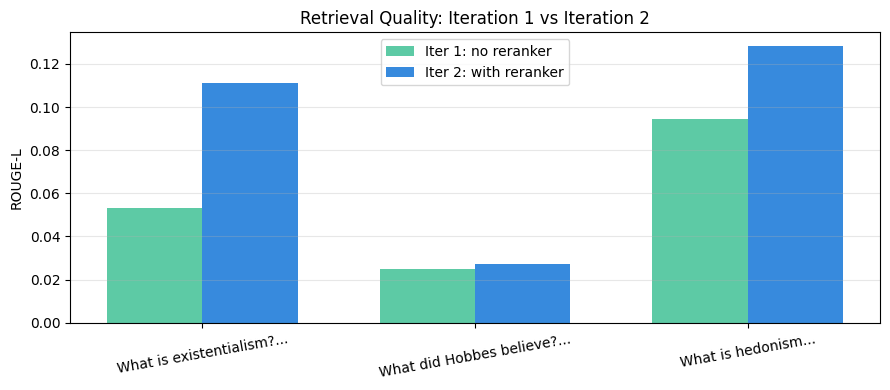

Avg ROUGE-L improvement: +0.031


In [15]:
# Iteration 1: dense retrieval, no reranker
# Iteration 2: dense retrieval + cross-encoder reranker

def ask_no_rerank(query, prompt_style="cot"):
    candidates = retrieve_dense(query, k=3)
    top_chunks  = [(chunks[i], s) for i, s in candidates]
    prompt      = build_prompt(query, top_chunks, prompt_style)
    return generate(prompt)

eval_questions = [
    ("What is existentialism?",     "Existentialism is a 20th-century philosophical movement emphasizing that individuals are entirely free and must create their own meaning, values, and purpose in an otherwise meaningless universe"),
    ("What did Hobbes believe?",         "Thomas Hobbes was an English philosopher who believed that human beings are inherently self-interested and that a strong, undivided central authority is necessary to prevent a chaotic state of nature"),
    ("What is hedonism",       "Hedonism is the philosophical doctrine and lifestyle that posits pleasure, and the avoidance of pain,as the primary, highest good and the main aim of human life"),
]

iter1_scores, iter2_scores = [], []

for question, reference in eval_questions:
    ans1 = ask_no_rerank(question)
    r1   = rouge.compute(predictions=[ans1], references=[reference])

    ans2, _ = ask(question)
    r2   = rouge.compute(predictions=[ans2], references=[reference])

    iter1_scores.append(r1["rougeL"])
    iter2_scores.append(r2["rougeL"])

    print(f"Q: {question}")
    print(f"  Iter 1 (no reranker) ROUGE-L:      {r1['rougeL']:.3f}")
    print(f"  Iter 2 (reranker)    ROUGE-L:      {r2['rougeL']:.3f}\n")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
x, w = np.arange(len(eval_questions)), 0.35
ax.bar(x - w/2, iter1_scores, w, label="Iter 1: no reranker",  color="#5DCAA5")
ax.bar(x + w/2, iter2_scores, w, label="Iter 2: with reranker", color="#378ADD")
ax.set_xticks(x)
ax.set_xticklabels([q[:30] + "..." for q, _ in eval_questions], rotation=10)
ax.set_ylabel("ROUGE-L")
ax.set_title("Retrieval Quality: Iteration 1 vs Iteration 2")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Avg ROUGE-L improvement: {np.mean(iter2_scores) - np.mean(iter1_scores):+.3f}")

In [17]:
from bert_score import score as bert_score_fn

def faithfulness_score(answer, retrieved_chunks):
    """Proxy faithfulness: fraction of answer sentences that contain
    at least one keyword from the retrieved context."""
    context_words = set(" ".join(c for c, _ in retrieved_chunks).lower().split())
    sentences = answer.split(".")
    grounded = sum(
        1 for s in sentences if s.strip() and
        any(w in context_words for w in s.lower().split() if len(w) > 4)
    )
    return round(grounded / max(len(sentences), 1), 3)

# Run all 3 metrics on your eval questions
print(f"{'Question':<35} {'ROUGE-L':>8} {'BERTScore':>10} {'Faithful':>10}")
print("-" * 65)

for question, reference in eval_questions:
    ans, top_chunks = ask(question)
    r    = rouge.compute(predictions=[ans], references=[reference])
    P, R, F = bert_score_fn([ans], [reference], lang="en", verbose=False)
    faith = faithfulness_score(ans, top_chunks)
    print(f"{question[:33]:<35} {r['rougeL']:>8.3f} {F.mean().item():>10.3f} {faith:>10.3f}")

Question                             ROUGE-L  BERTScore   Faithful
-----------------------------------------------------------------


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


What did Hobbes believe?               0.025      0.818      0.966


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


What is hedonism                       0.040      0.824      0.886
